# Syntecxhub Fourth Task Project-3

# Project Name : "End-to-end Capstone"

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. Load dataset

In [6]:
FILE_PATH = "superstore.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Rows: 9994
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### 3. Dataset inspection

In [7]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst five rows:")
display(df.head())

Dataset shape:
(9994, 21)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

First five rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### 4. Missing-value analysis

In [8]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percentage = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_report

,Missing Values,Missing Percentage
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Customer Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0


### 5. Duplicate analysis

In [9]:
duplicate_count = df.duplicated().sum()

print(
    f"Number of duplicate rows: {duplicate_count}"
)

Number of duplicate rows: 0


### 6. Data cleaning

In [10]:
# Make a copy so the original data remains unchanged
clean_df = df.copy()

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Convert dates
clean_df["Order Date"] = pd.to_datetime(
    clean_df["Order Date"],
    errors="coerce"
)

clean_df["Ship Date"] = pd.to_datetime(
    clean_df["Ship Date"],
    errors="coerce"
)

# Convert numerical columns
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

for column in numeric_columns:
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

# Remove records with missing critical values
clean_df = clean_df.dropna(
    subset=[
        "Order Date",
        "Sales",
        "Profit"
    ]
)

print("Cleaning completed.")
print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))

Cleaning completed.
Original rows: 9994
Cleaned rows: 9994


### 7. Feature engineering

In [11]:
clean_df["Year"] = (
    clean_df["Order Date"]
    .dt.year
)

clean_df["Month"] = (
    clean_df["Order Date"]
    .dt.month
)

clean_df["Month Name"] = (
    clean_df["Order Date"]
    .dt.strftime("%b")
)

clean_df["Year-Month"] = (
    clean_df["Order Date"]
    .dt.to_period("M")
    .astype(str)
)

clean_df["Profit Margin"] = np.where(
    clean_df["Sales"] != 0,
    clean_df["Profit"] / clean_df["Sales"] * 100,
    0
)

clean_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Year-Month,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Nov,2016-11,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Nov,2016-11,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Jun,2016-06,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Oct,2015-10,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Oct,2015-10,11.25


## KPI Analysis

### 8. Calculate KPIs

In [12]:
total_sales = clean_df["Sales"].sum()

total_profit = clean_df["Profit"].sum()

total_quantity = clean_df["Quantity"].sum()

total_orders = clean_df["Order ID"].nunique()

average_order_value = (
    total_sales / total_orders
)

profit_margin = (
    total_profit / total_sales * 100
)

print("=" * 45)
print("KEY PERFORMANCE INDICATORS")
print("=" * 45)

print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Profit      : ${total_profit:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Average Order     : ${average_order_value:,.2f}")
print(f"Profit Margin     : {profit_margin:.2f}%")

KEY PERFORMANCE INDICATORS
Total Sales       : $2,297,200.86
Total Profit      : $286,397.02
Total Orders      : 5,009
Total Quantity    : 37,873
Average Order     : $458.61
Profit Margin     : 12.47%


## Exploratory Data Analysis

### 9. Sales by category

In [13]:
category_sales = (
    clean_df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

### 10. Category visualization

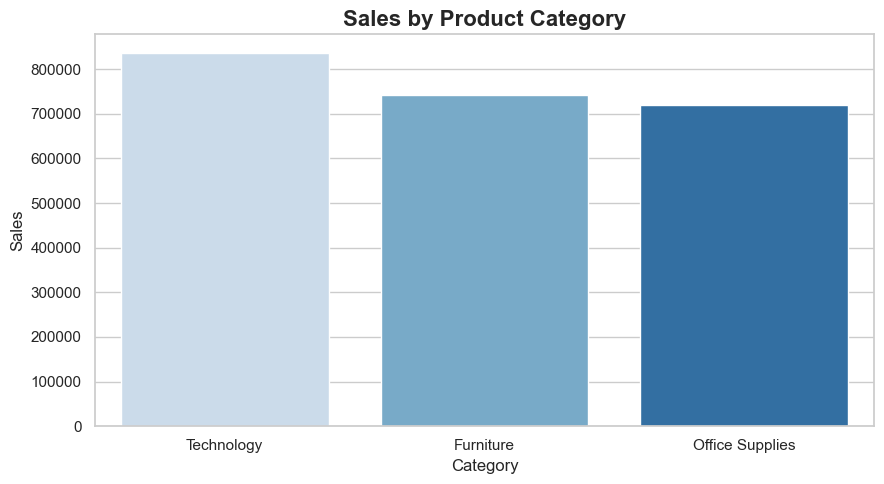

In [14]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    hue=category_sales.index,
    legend=False,
    palette="Blues"
)

plt.title(
    "Sales by Product Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "sales_by_category.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### 11. Top products

In [15]:
top_products = (
    clean_df
    .groupby("Product Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .sort_values(
        "Sales",
        ascending=False
    )
    .head(10)
)

top_products

,Sales,Profit,Quantity
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,2.519993e+04,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7.753039e+03,31
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1.811078e+03,6
HON 5400 Series Task Chairs for Big and Tall,21870.576,5.684342e-14,39
GBC DocuBind TL300 Electric Binding System,19823.479,2.233505e+03,37
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,7.609800e+02,48
Hewlett Packard LaserJet 3310 Copier,18839.686,6.983884e+03,38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4.094977e+03,12
GBC DocuBind P400 Electric Binding System,17965.068,-1.878166e+03,27


### 12. Top products visualization

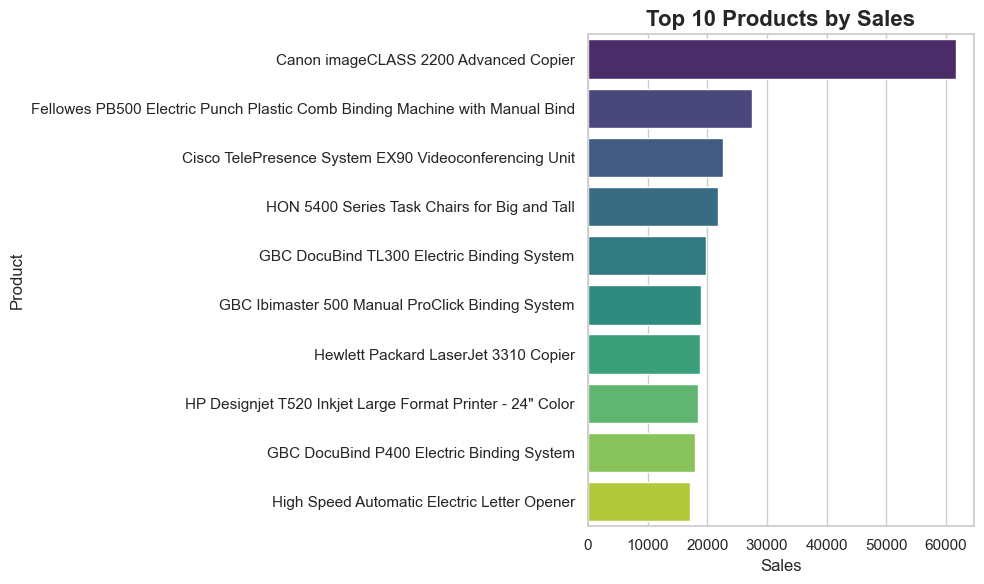

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products.reset_index(),
    x="Sales",
    y="Product Name",
    hue="Product Name",
    legend=False,
    palette="viridis"
)

plt.title(
    "Top 10 Products by Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "top_products.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Regional Analysis

### 13. Region performance

In [17]:
region_analysis = (
    clean_df
    .groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values(
        "Sales",
        ascending=False
    )
)

region_analysis

,Sales,Profit,Orders
Region,,,
West,725457.8245,108418.4489,1611
East,678781.2400,91522.7800,1401
Central,501239.8908,39706.3625,1175
South,391721.9050,46749.4303,822


### 14. Regional visualization

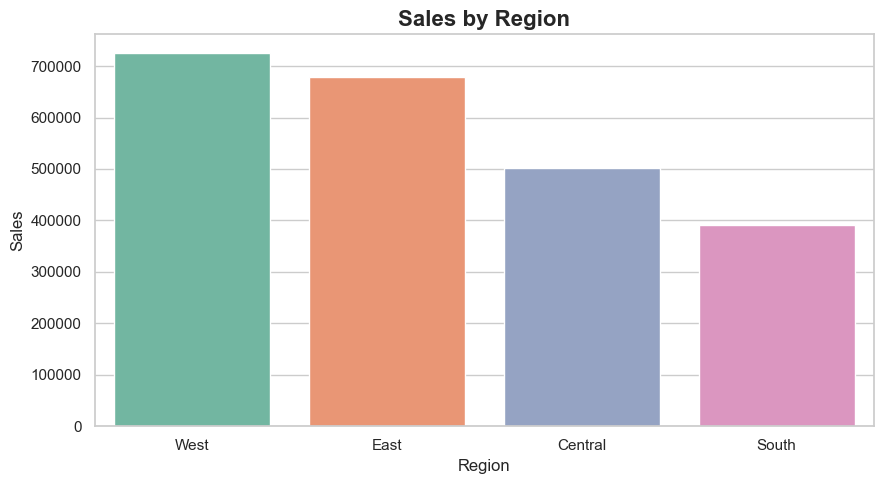

In [18]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=region_analysis.reset_index(),
    x="Region",
    y="Sales",
    hue="Region",
    legend=False,
    palette="Set2"
)

plt.title(
    "Sales by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "sales_by_region.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Time / Seasonal Analysis

### 15.  Monthly sales

In [19]:
monthly_sales = (
    clean_df
    .groupby("Year-Month")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

monthly_sales.head()

,Year-Month,Sales,Profit
0,2014-01,14236.895,2450.1907
1,2014-02,4519.892,862.3084
2,2014-03,55691.009,498.7299
3,2014-04,28295.345,3488.8352
4,2014-05,23648.287,2738.7096


### 16. Sales trend visualization

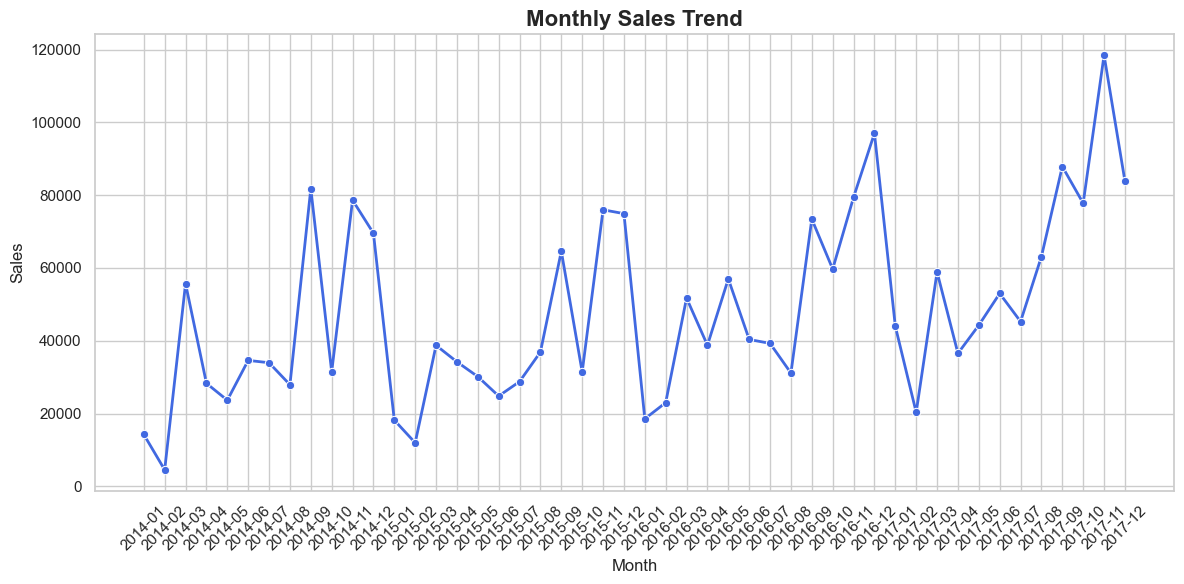

In [20]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Year-Month",
    y="Sales",
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.title(
    "Monthly Sales Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "monthly_sales_trend.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Profit Analysis

### 17. Profit by category

In [21]:
category_profit = (
    clean_df
    .groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

### 18. Sales vs profit

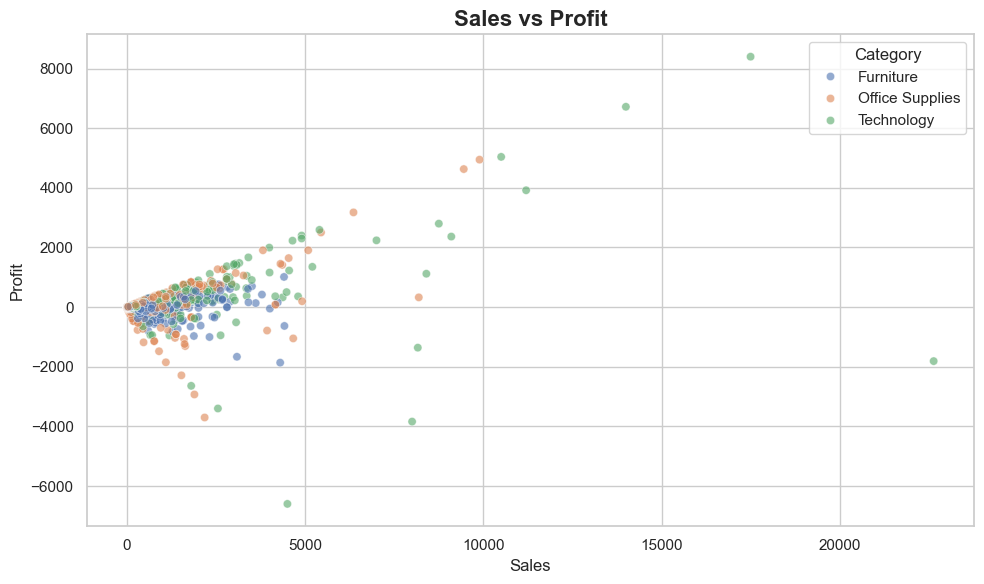

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="Sales",
    y="Profit",
    hue="Category",
    alpha=0.6
)

plt.title(
    "Sales vs Profit",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "sales_vs_profit.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Discount Analysis

### 19. Discount vs profit

In [23]:
discount_analysis = (
    clean_df
    .groupby("Discount")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .reset_index()
)

discount_analysis

,Discount,Sales,Profit,Orders
0,0.00,1.087908e+06,320987.6032,2644
1,0.10,5.436935e+04,9029.1770,89
2,0.15,2.755852e+04,1418.9915,51
3,0.20,7.645944e+05,90337.3060,2407
4,0.30,1.032267e+05,-10369.2774,211
5,0.32,1.449346e+04,-2391.1377,27
6,0.40,1.164178e+05,-23057.0504,185
7,0.45,5.484974e+03,-2493.1111,10
8,0.50,5.891854e+04,-20506.4281,64
9,0.60,6.644700e+03,-5944.6552,127


### 20. Discount visualization

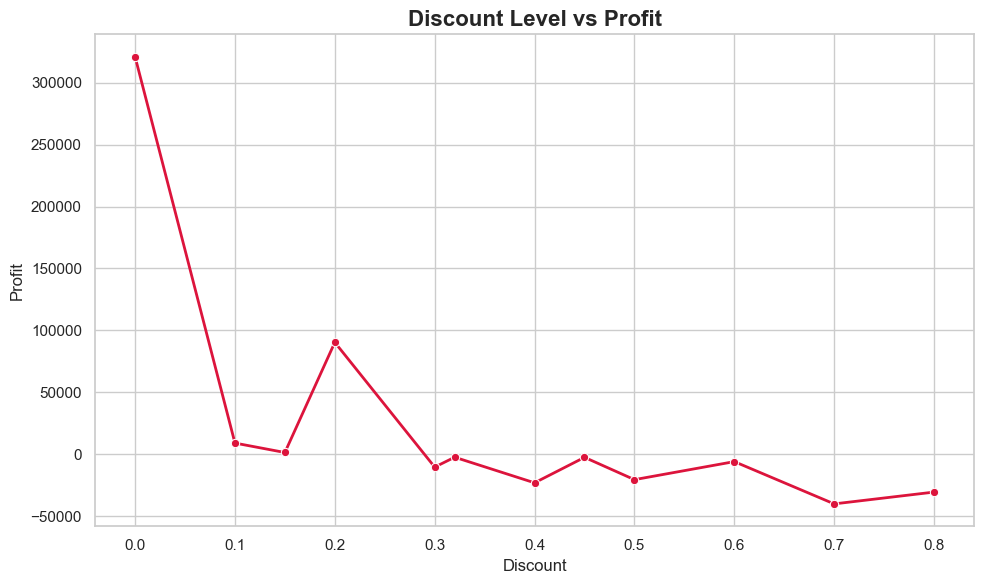

In [24]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=discount_analysis,
    x="Discount",
    y="Profit",
    marker="o",
    linewidth=2,
    color="crimson"
)

plt.title(
    "Discount Level vs Profit",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "discount_vs_profit.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Automatic Insights

### 21. Generate findings

In [25]:
# Top category
top_category = category_sales.idxmax()

top_category_sales = category_sales.max()

# Best region
best_region = region_analysis["Sales"].idxmax()

best_region_sales = region_analysis.loc[
    best_region,
    "Sales"
]

# Best product
best_product = top_products.index[0]

best_product_sales = top_products.iloc[0]["Sales"]

# Highest sales month
best_month_row = monthly_sales.loc[
    monthly_sales["Sales"].idxmax()
]

best_month = best_month_row["Year-Month"]

best_month_sales = best_month_row["Sales"]

# Most profitable category
best_profit_category = category_profit.idxmax()

best_profit = category_profit.max()

print("ACTIONABLE INSIGHTS")
print("=" * 60)

print(
    f"1. {top_category} is the leading category, "
    f"generating ${top_category_sales:,.2f} in sales."
)

print(
    f"2. {best_region} is the strongest region, "
    f"with ${best_region_sales:,.2f} in sales."
)

print(
    f"3. {best_product} is the highest-selling product, "
    f"generating ${best_product_sales:,.2f}."
)

print(
    f"\nPeak sales occurred in {best_month}, "
    f"with ${best_month_sales:,.2f} in revenue."
)

print(
    f"The most profitable category is "
    f"{best_profit_category}, generating "
    f"${best_profit:,.2f} profit."
)

ACTIONABLE INSIGHTS
1. Technology is the leading category, generating $836,154.03 in sales.
2. West is the strongest region, with $725,457.82 in sales.
3. Canon imageCLASS 2200 Advanced Copier is the highest-selling product, generating $61,599.82.

Peak sales occurred in 2017-11, with $118,447.82 in revenue.
The most profitable category is Technology, generating $145,454.95 profit.


## Three Actionable Recommendations

### 22 — Business recommendations

In [ ]:
## Actionable Recommendations

### 1. Invest in high-performing categories

The strongest product category should receive additional
marketing and inventory attention. The business should
ensure sufficient stock during periods of high demand.

### 2. Strengthen regional strategy

The best-performing region should be used as a benchmark
for other regions. The company can investigate its pricing,
product mix, customer behavior and marketing strategy and
apply successful practices to weaker regions.

### 3. Improve product and discount strategy

High-sales products should be monitored for profitability,
not just revenue. Excessive discounting can increase sales
while reducing profit, so promotions should focus on products
and customer segments where discounts generate profitable
additional demand.

## 23. Export Clean Dataset

In [29]:
clean_df.to_csv(
    OUTPUT_DIR / "cleaned_sales_data.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


## 24. Export Analysis Results

In [30]:
category_sales.to_csv(
    OUTPUT_DIR / "category_sales.csv"
)

region_analysis.to_csv(
    OUTPUT_DIR / "region_analysis.csv"
)

top_products.to_csv(
    OUTPUT_DIR / "top_products.csv"
)

monthly_sales.to_csv(
    OUTPUT_DIR / "monthly_sales.csv",
    index=False
)

print("Analysis files exported successfully.")

Analysis files exported successfully.


## Final Report

### 25 — Final project summary

In [ ]:
# Final Findings

## KPI Summary

| KPI | Result |
|---|---|
| Total Sales | Calculated from dataset |
| Total Profit | Calculated from dataset |
| Total Orders | Calculated from dataset |
| Average Order Value | Calculated from dataset |
| Profit Margin | Calculated from dataset |

## Key Findings

1. The leading product category was identified based on total sales.
2. The strongest region was identified using regional revenue.
3. The top-performing product was identified based on total sales.
4. Monthly analysis identified the peak sales period.
5. Profitability was analyzed alongside sales to avoid focusing only on revenue.

## Business Recommendations

- Increase inventory and marketing for high-performing categories.
- Use successful regional strategies to improve weaker regions.
- Optimize discounting to increase sales without sacrificing profit.

## Conclusion

This project demonstrates a complete data-analysis workflow,
including data cleaning, exploratory analysis, KPI calculation,
visualization, interpretation and business recommendations.